# LoVoCCS morphology: Hot ICM, BCG, red sequence, and WL mass **centroids**

This section of the project investigates the separation between major non-gaseous components of LoVoCCS galaxy clusters and the hot, X-ray emitting, intra-cluster medium. Offsets between the different components of galaxy clusters can elucidate the history of mergers or astrophysical processes in these systems. Offsets between different cluster components can also cause problems for surveys such as the Dark Energy Survey (DES), where a reliable central coordinate is required to ensure that stacked clusters (mostly for weak-lensing signal) are aligned correctly.

## Main takeaways 

In summary:

* We calculate the angular separation between the centroid coordinate of the hot ICM X-ray emission, and other major components of the galaxy clusters (BCG, red-sequence, and weak-lensing mass distribution).
* Assuming a cosmological model, and making use of the known LoVoCCS galaxy cluster redshifts, the angular separations are converted to proper distances.
* Minimum and maximum separations for ICM-BCG are 2.05 kpc (LoVoCCS-15) and 1076.50 kpc (LoVoCCS-66B); for ICM-red sequence are 10.40 kpc (LoVoCCS-80) and 1018.86 kpc (LoVoCCS-66B); and for ICM-WLM are 7.53 kpc (LoVoCCS-48B) and 1001.07 kpc (LoVoCCS-93A).
* **Note that the maximum separations are in systems where X-LoVoCCS has split the overall LoVoCCS galaxy cluster into multiple components.**
* Considering the overall sample, the ICM-BCG separation is the smallest, with 67.7% of the LoVoCCS clusters *for which an ICM and BCG centroid have been measured* (a total of 62) having a separation less than 100 kpc. Of the 61 with measured ICM-RS separations, 44.3% are smaller than 100 kpc, and of the 59 with ICM-WLM separations 37.3% are smaller than 100 kpc.

* When we look at separation _vectors_, which have been rotated so that they are parallel and perpendicular to the position angle of the hot ICM, we find that the distributions of separations parallel to the semi-major axis of the ICM are wider than their perpendicular equivalents. 

## Import Statements

In [1]:
import pandas as pd
pd.set_option('display.max_columns', 500)
import numpy as np
from matplotlib import pyplot as plt
import os
from astropy.units import Quantity

# This adds the directory above to the path, allowing me to import the common functions that I've written in
#  common.py - this just saves me repeating boring code and makes sure its all consistent
import sys
sys.path.insert(0, '../')
from common import lovoccs_cosmo, haversine

# We could just re-implement this, but it is already there in XGA
from xga.sourcetools.misc import ang_to_rad

%matplotlib inline

## Useful values

Here we set up any values that are useful to several parts of the analysis in this notebook, and that we might wish to change in the future:

In [2]:
SEP_CONF_LEVEL = 95.4

## Output paths

Paths to save comparison figures and any output results files - defined here to avoid repetition and make the code easier to read: 

In [3]:
sep_fig_path = "../../outputs/figures/positions_and_morphology/coordinate_offsets/"
os.makedirs(sep_fig_path, exist_ok=True)

sep_res_path = "../../outputs/result_files/positions_and_morphology/"
os.makedirs(sep_res_path, exist_ok=True)

## Cosmological model

We employ the same cosmological model utilized in the LoVoCCS-I & II analyses (Fu et al. [2022](https://ui.adsabs.harvard.edu/abs/2022ApJ...933...84F/abstract), [2024](https://ui.adsabs.harvard.edu/abs/2024ApJ...974...69F/abstract)):

In [4]:
lovoccs_cosmo

LambdaCDM(name=None, H0=<Quantity 71. km / (Mpc s)>, Om0=0.2648, Ode0=0.7352, Tcmb0=<Quantity 0. K>, Neff=3.04, m_nu=None, Ob0=0.0448)

## Loading data files

Important considerations for this dataset:

* Some clusters selected for LoVoCCS have been identified as multiple blended systems in the course of the X-LoVoCCS project - other LoVoCCS works may only have entries/have made measurements for the overall system.
* Not all LoVoCCS-II galaxy clusters have XMM data available - as such we will not yet have measured X-ray centroids for them.

### X-LoVoCCS-I base sample

In [5]:
xlovoccs_base = pd.read_csv("../../sample_files/X-LoVoCCSI.csv")
xlovoccs_base.insert(0, 'name', xlovoccs_base['LoVoCCSID'].apply(lambda x: "LoVoCCS-" + str(x)))
xlovoccs_base.head(6)

,name,LoVoCCSID,parent_LoVoCCSID,Name,start_ra,start_dec,MCXC_Redshift,MCXC_R500,MCXC_RA,MCXC_DEC,manual_xray_ra,manual_xray_dec,MCXC_Lx500_0.1_2.4
0,LoVoCCS-1,1,1,A2029,227.734300,5.745471,0.0766,1.3344,227.73000,5.720000,227.734300,5.745471,8.726709e+44
1,LoVoCCS-2,2,2,A401,44.740000,13.580000,0.0739,1.2421,44.74000,13.580000,NaN,NaN,6.088643e+44
2,LoVoCCS-4,4,4,A85,10.458750,-9.301944,0.0555,1.2103,10.45875,-9.301944,NaN,NaN,5.100085e+44
3,LoVoCCS-5,5,5,A3667,303.157313,-56.845978,0.0556,1.1990,303.13000,-56.830000,303.157313,-56.845978,4.871933e+44
4,LoVoCCS-7,7,7,A3827,330.480000,-59.950000,0.0980,1.1367,330.48000,-59.950000,NaN,NaN,4.204419e+44
5,LoVoCCS-9,9,9,A3266,67.830487,-61.447401,0.0589,1.1485,67.85000,-61.440000,67.830487,-61.447401,3.977333e+44


### X-LoVoCCS-I ICM centroid positions

This contains the centroid positions of the hot intra-cluster medium measured as part of this work:

In [6]:
xlovoccs_centroid = pd.read_csv("../../outputs/result_files/positions_and_morphology/xmm_500kpc_centroid_posang.csv")
xlovoccs_centroid.head(6)

,name,cent_ra,cent_ra-,cent_ra+,cent_dec,cent_dec-,cent_dec+,position_angle,position_angle-,position_angle+,ax_ratio,ax_ratio-,ax_ratio+
0,LoVoCCS-1,227.73324,0.00002,0.00002,5.74338,0.00003,0.00003,-73.0512,0.2030,0.2157,0.9202,0.0011,0.0012
1,LoVoCCS-2,44.73661,0.00017,0.00015,13.57730,0.00018,0.00016,23.7327,4.3632,3.8393,0.9746,0.0049,0.0043
2,LoVoCCS-4A,10.46006,0.00003,0.00004,-9.30457,0.00004,0.00004,67.2727,0.2179,0.1952,0.8910,0.0009,0.0010
3,LoVoCCS-4B,10.46330,0.00018,0.00016,-9.43280,0.00024,0.00029,-71.9520,0.9161,1.0538,0.9176,0.0047,0.0038
4,LoVoCCS-5,303.14189,0.00014,0.00015,-56.83829,0.00009,0.00007,40.0924,0.2190,0.2355,0.8262,0.0011,0.0012
5,LoVoCCS-7,330.47766,0.00011,0.00024,-59.94796,0.00011,0.00011,-78.3924,0.9435,0.8295,0.9519,0.0032,0.0037


### X-LoVoCCS-I ICM peak positions

This contains the coordinates of the X-ray peak positions we have measured for our X-LoVoCCS clusters:

In [7]:
xlovoccs_peak = pd.read_csv("../../outputs/result_files/positions_and_morphology/xmm_peak_coords.csv")
xlovoccs_peak.head(6)

,name,peak_ra,peak_dec
0,LoVoCCS-1,227.733253,5.745184
1,LoVoCCS-2,44.750675,13.594567
2,LoVoCCS-4A,10.460369,-9.303375
3,LoVoCCS-4B,10.460369,-9.303375
4,LoVoCCS-5,303.100675,-56.851435
5,LoVoCCS-7,330.466217,-59.948751


### LoVoCCS-II BCG, red sequence, and mass distribution angles

Here we load a results file from another LoVoCCS work ([Fu et al. 2024](https://ui.adsabs.harvard.edu/abs/2024ApJ...974...69F/abstract)) which contains the positions of the BCGs, and centroid positions of the red-sequence and overall mass (represented by 2D weak-lensing) distributions.

In cases with multiple X-LoVoCCS-identified sub-clusters, we assign the red-sequence/weak-lensing mass position angle to the 'main' X-ray counterpart.

In [8]:
lovoccsII_morph = pd.read_csv("../../sample_files/LoVoCCSII_centroid_pa_results.csv")
lovoccsII_morph.head(6)

,parent_LoVoCCSID,cluster,redshift_target,BCG_ra,BCG_dec,mass_map_ra,mass_map_dec,RS_map_ra,RS_map_dec,BCG_angle,mass_map_angle_05,mass_map_angle_10,mass_map_angle_20,RS_map_angle_05,RS_map_angle_10,RS_map_angle_20,cluster_type
0,1,A2029,0.0773,227.733771,5.744819,227.731704,5.775644,227.742692,5.770095,-62.61,84.602196,83.570516,-69.689253,-74.378012,-74.170775,-84.280216,a
1,2,A401,0.0743,44.740801,13.582686,44.741462,13.582399,44.742694,13.579045,-63.16,-6.824412,0.640114,-24.654011,-61.347490,-47.585406,-58.138832,a
2,4,A85,0.0556,10.460319,-9.303484,10.446739,-9.332133,10.405090,-9.312744,58.59,-70.095509,-84.031952,-40.610942,84.708468,72.220682,74.508138,b
3,5,A3667,0.0552,303.113931,-56.826788,303.135914,-56.845641,303.150738,-56.836339,44.27,-68.929259,79.595996,-84.325048,38.482847,44.175107,48.139765,a
4,7,A3827,0.0972,330.469621,-59.946597,330.458667,-59.942374,330.481129,-59.937518,72.40,78.181991,68.843089,56.923349,72.853008,64.101562,83.362138,a
5,9,A3266,0.0577,67.805321,-61.453344,67.799351,-61.432924,67.823175,-61.445007,-9.76,-74.274322,80.479806,86.423098,-25.382462,-24.227173,-43.988502,a


### Combining tables

In [9]:
xlovoccs_samp = pd.merge(xlovoccs_base, xlovoccs_centroid, left_on='name', right_on='name', how='outer')
xlovoccs_samp = pd.merge(xlovoccs_samp, xlovoccs_peak, left_on='name', right_on='name', how='outer')
xlovoccs_samp = pd.merge(xlovoccs_samp, lovoccsII_morph, left_on='parent_LoVoCCSID', right_on='parent_LoVoCCSID', how='inner')
xlovoccs_samp = xlovoccs_samp.sort_values('parent_LoVoCCSID').reset_index(drop=True)
xlovoccs_samp.head(6)

,name,LoVoCCSID,parent_LoVoCCSID,Name,start_ra,start_dec,MCXC_Redshift,MCXC_R500,MCXC_RA,MCXC_DEC,manual_xray_ra,manual_xray_dec,MCXC_Lx500_0.1_2.4,cent_ra,cent_ra-,cent_ra+,cent_dec,cent_dec-,cent_dec+,position_angle,position_angle-,position_angle+,ax_ratio,ax_ratio-,ax_ratio+,peak_ra,peak_dec,cluster,redshift_target,BCG_ra,BCG_dec,mass_map_ra,mass_map_dec,RS_map_ra,RS_map_dec,BCG_angle,mass_map_angle_05,mass_map_angle_10,mass_map_angle_20,RS_map_angle_05,RS_map_angle_10,RS_map_angle_20,cluster_type
0,LoVoCCS-1,1,1.0,A2029,227.734300,5.745471,0.0766,1.3344,227.73000,5.720000,227.734300,5.745471,8.726709e+44,227.73324,0.00002,0.00002,5.74338,0.00003,0.00003,-73.0512,0.2030,0.2157,0.9202,0.0011,0.0012,227.733253,5.745184,A2029,0.0773,227.733771,5.744819,227.731704,5.775644,227.742692,5.770095,-62.61,84.602196,83.570516,-69.689253,-74.378012,-74.170775,-84.280216,a
1,LoVoCCS-2,2,2.0,A401,44.740000,13.580000,0.0739,1.2421,44.74000,13.580000,NaN,NaN,6.088643e+44,44.73661,0.00017,0.00015,13.57730,0.00018,0.00016,23.7327,4.3632,3.8393,0.9746,0.0049,0.0043,44.750675,13.594567,A401,0.0743,44.740801,13.582686,44.741462,13.582399,44.742694,13.579045,-63.16,-6.824412,0.640114,-24.654011,-61.347490,-47.585406,-58.138832,a
2,LoVoCCS-4,4,4.0,A85,10.458750,-9.301944,0.0555,1.2103,10.45875,-9.301944,NaN,NaN,5.100085e+44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A85,0.0556,10.460319,-9.303484,10.446739,-9.332133,10.405090,-9.312744,58.59,-70.095509,-84.031952,-40.610942,84.708468,72.220682,74.508138,b
3,LoVoCCS-5,5,5.0,A3667,303.157313,-56.845978,0.0556,1.1990,303.13000,-56.830000,303.157313,-56.845978,4.871933e+44,303.14189,0.00014,0.00015,-56.83829,0.00009,0.00007,40.0924,0.2190,0.2355,0.8262,0.0011,0.0012,303.100675,-56.851435,A3667,0.0552,303.113931,-56.826788,303.135914,-56.845641,303.150738,-56.836339,44.27,-68.929259,79.595996,-84.325048,38.482847,44.175107,48.139765,a
4,LoVoCCS-7,7,7.0,A3827,330.480000,-59.950000,0.0980,1.1367,330.48000,-59.950000,NaN,NaN,4.204419e+44,330.47766,0.00011,0.00024,-59.94796,0.00011,0.00011,-78.3924,0.9435,0.8295,0.9519,0.0032,0.0037,330.466217,-59.948751,A3827,0.0972,330.469621,-59.946597,330.458667,-59.942374,330.481129,-59.937518,72.40,78.181991,68.843089,56.923349,72.853008,64.101562,83.362138,a
5,LoVoCCS-9,9,9.0,A3266,67.830487,-61.447401,0.0589,1.1485,67.85000,-61.440000,67.830487,-61.447401,3.977333e+44,67.84439,0.00007,0.00008,-61.43277,0.00003,0.00005,-33.7707,0.2053,0.2984,0.9303,0.0007,0.0006,67.812127,-61.453695,A3266,0.0577,67.805321,-61.453344,67.799351,-61.432924,67.823175,-61.445007,-9.76,-74.274322,80.479806,86.423098,-25.382462,-24.227173,-43.988502,a


### Reading out hot ICM central positions

We have two definitions of galaxy cluster position extracted from our X-ray data, the centroids of the surface brightness distribution, and the position of the peak in X-ray brightness. Both definitions may act as comparisons for LoVoCCS-II positions in the course of this notebook, so we read them out of the dataframe:

In [10]:
# Measured ICM centroid coordinates
icm_cent = Quantity(xlovoccs_samp[['cent_ra', 'cent_dec']].values, 'deg')
# And uncertainties on said coordinates
icm_cent_ra_err = Quantity(xlovoccs_samp[['cent_ra-', 'cent_ra+']].values, 'deg')
icm_cent_dec_err = Quantity(xlovoccs_samp[['cent_dec-', 'cent_dec+']].values, 'deg')

# The X-ray peak coordinates we measured
icm_peak = Quantity(xlovoccs_samp[['peak_ra', 'peak_dec']].values)

## Reading out LoVoCCS-II positions

To make things neater, we also read out the various central positions of LoVoCCS clusters into their own variables:

In [11]:
# These are all self-explanatory really
bcg_cent = Quantity(xlovoccs_samp[['BCG_ra', 'BCG_dec']].values, 'deg')
red_seq_cent = Quantity(xlovoccs_samp[['RS_map_ra', 'RS_map_dec']].values, 'deg')
wlm_cent = Quantity(xlovoccs_samp[['mass_map_ra', 'mass_map_dec']].values, 'deg')

## Separation-from-ICM distributions

Here we explore how the centroids of the X-ray emission from LoVoCCS clusters are separated from centroids of other components (BCG, red sequence, total mass distribution).

### Calculating $\Delta[C^{\rm{ICM}}_{x,y}-C^{\rm{...}}_{x,y}]$ distributions

<span style="color:teal">When we decide on fiducial redshifts for the LoVoCCS clusters, this might have to change.</span>

Here we calculate the angular separation between various optical-components of the LoVoCCS galaxy clusters, and the X-ray centroids - the Haversine distance metric is used, though at these separations we do not expect it to diverge meaningfully from Euclidean distance, the Haversine calculation does handle the distance between, for instance 0.1 and 359.9 degrees properly. An assumed cosmological model, which is the same across all LoVoCCS analyses (look near the top of the notebook), combined with the cluster redshifts converts the angular separations into proper distances:

In [12]:
delta_icm_bcg = haversine(icm_cent[:, 0], icm_cent[:, 1], bcg_cent[:, 0], bcg_cent[:, 1])
delta_icm_red_seq = haversine(icm_cent[:, 0], icm_cent[:, 1], red_seq_cent[:, 0], red_seq_cent[:, 1])
delta_icm_wlm = haversine(icm_cent[:, 0], icm_cent[:, 1], wlm_cent[:, 0], wlm_cent[:, 1])

# Now we must make sure that these angular separations are turned into a proper distance, so we can make 
#  like-for-like comparisons between different LoVoCCS systems
prop_delta_icm_bcg = ang_to_rad(delta_icm_bcg, xlovoccs_samp['MCXC_Redshift'].values, lovoccs_cosmo)
prop_delta_icm_red_seq = ang_to_rad(delta_icm_red_seq, xlovoccs_samp['MCXC_Redshift'].values, lovoccs_cosmo)
prop_delta_icm_wlm = ang_to_rad(delta_icm_wlm, xlovoccs_samp['MCXC_Redshift'].values, lovoccs_cosmo)

### Saving separations to a results file

Separations are stored in a results file, as they may be useful in other parts of our analyses:

In [13]:
sep_data = np.vstack([delta_icm_bcg.value, prop_delta_icm_bcg.value, delta_icm_red_seq.value, prop_delta_icm_red_seq.value, 
                      delta_icm_wlm.value, prop_delta_icm_wlm.value]).T.round(5)
sep_data = np.append(xlovoccs_samp['name'].values[..., None], sep_data, axis=1)
sep_cols = ['name', 'icm_bcg_arcmin_sep', 'icm_bcg_kpc_sep', 'icm_red_seq_arcmin_sep', 'icm_red_seq_kpc_sep', 
            'icm_wlm_arcmin_sep', 'icm_wlm_kpc_sep']
sep_df = pd.DataFrame(sep_data, columns=sep_cols)
sep_df.to_csv(sep_res_path + "icm_component_centroid_separations.csv", index=False)
sep_df

,name,icm_bcg_arcmin_sep,icm_bcg_kpc_sep,icm_red_seq_arcmin_sep,icm_red_seq_kpc_sep,icm_wlm_arcmin_sep,icm_wlm_kpc_sep
0,LoVoCCS-1,0.09202,7.91714,1.70029,146.28484,1.93801,166.73691
1,LoVoCCS-2,0.40944,34.08941,0.37973,31.6154,0.42231,35.16104
2,LoVoCCS-4,NaN,NaN,NaN,NaN,NaN,NaN
3,LoVoCCS-5,1.81372,116.02293,0.54357,34.77165,0.56842,36.36157
4,LoVoCCS-7,0.48915,52.55452,0.66016,70.92831,1.18767,127.60351
...,...,...,...,...,...,...,...
61,LoVoCCS-121,11.03528,786.07889,8.36273,595.70455,10.22107,728.07991
62,LoVoCCS-122,NaN,NaN,NaN,NaN,NaN,NaN
63,LoVoCCS-123,13.88465,870.22781,14.48,907.54168,14.14657,886.64398
64,LoVoCCS-131,0.10964,11.09012,1.92808,195.02436,0.42924,43.41697


### Finding minimum and maximum separations

We will examine the full distributions, but in the meantime it might be instructive to look at the galaxy clusters with the smallest and largest distances between the centroids of their different components. To remove the effects of the Universe's expansion, we will use the 'proper distance' separations.

The largest separations may be the result of the X-LoVoCCS work splitting LoVoCCS clusters into multiple sub-clusters, but there being only a single, overall, centroid position from the LoVoCCS-II analysis. Names with A, B, or C at the end indicate that the LoVoCCS cluster has been split by X-LoVoCCS.

#### ICM-BCG

In [14]:
# Simply finding the index of the smallest proper separation entry, which we then use to find the
#  name of the cluster it corresponds to
icm_bcg_min_ind = np.nanargmin(prop_delta_icm_bcg)
icm_bcg_min_val = prop_delta_icm_bcg[icm_bcg_min_ind].round(4)
icm_bcg_min_name = xlovoccs_samp['name'].values[icm_bcg_min_ind]

# The same process but for the largest proper separation
icm_bcg_max_ind = np.nanargmax(prop_delta_icm_bcg)
icm_bcg_max_val = prop_delta_icm_bcg[icm_bcg_max_ind].round(4)
icm_bcg_max_name = xlovoccs_samp['name'].values[icm_bcg_max_ind]

print(icm_bcg_min_name, 'has the smallest proper separation between ICM and BCG centroids -', icm_bcg_min_val)
print(icm_bcg_max_name, 'has the largest proper separation between ICM and BCG centroids -', icm_bcg_max_val)

LoVoCCS-15 has the smallest proper separation between ICM and BCG centroids - 2.0534 kpc
LoVoCCS-66B has the largest proper separation between ICM and BCG centroids - 1076.4028 kpc


#### ICM-Red Sequence

In [15]:
# Simply finding the index of the smallest proper separation entry, which we then use to find the
#  name of the cluster it corresponds to
icm_red_seq_min_ind = np.nanargmin(prop_delta_icm_red_seq)
icm_red_seq_min_val = prop_delta_icm_red_seq[icm_red_seq_min_ind].round(4)
icm_red_seq_min_name = xlovoccs_samp['name'].values[icm_red_seq_min_ind]

# The same process but for the largest proper separation
icm_red_seq_max_ind = np.nanargmax(prop_delta_icm_red_seq)
icm_red_seq_max_val = prop_delta_icm_red_seq[icm_red_seq_max_ind].round(4)
icm_red_seq_max_name = xlovoccs_samp['name'].values[icm_red_seq_max_ind]

print(icm_red_seq_min_name, 'has the smallest proper separation between ICM and Red Sequence centroids -', icm_red_seq_min_val)
print(icm_red_seq_max_name, 'has the largest proper separation between ICM and Red Sequence centroids -', icm_red_seq_max_val)

LoVoCCS-80 has the smallest proper separation between ICM and Red Sequence centroids - 10.403 kpc
LoVoCCS-66B has the largest proper separation between ICM and Red Sequence centroids - 1018.8632 kpc


#### ICM-WLM

In [16]:
# Simply finding the index of the smallest proper separation entry, which we then use to find the
#  name of the cluster it corresponds to
icm_wlm_min_ind = np.nanargmin(prop_delta_icm_wlm)
icm_wlm_min_val = prop_delta_icm_wlm[icm_wlm_min_ind].round(4)
icm_wlm_min_name = xlovoccs_samp['name'].values[icm_wlm_min_ind]

# The same process but for the largest proper separation
icm_wlm_max_ind = np.nanargmax(prop_delta_icm_wlm)
icm_wlm_max_val = prop_delta_icm_wlm[icm_wlm_max_ind].round(4)
icm_wlm_max_name = xlovoccs_samp['name'].values[icm_wlm_max_ind]

print(icm_wlm_min_name, 'has the smallest proper separation between ICM and WLM centroids -', icm_wlm_min_val)
print(icm_wlm_max_name, 'has the largest proper separation between ICM and WLM centroids -', icm_wlm_max_val)

LoVoCCS-48A has the smallest proper separation between ICM and WLM centroids - 7.531 kpc
LoVoCCS-93A has the largest proper separation between ICM and WLM centroids - 1001.0738 kpc


### How do separations of different cluster components compare?

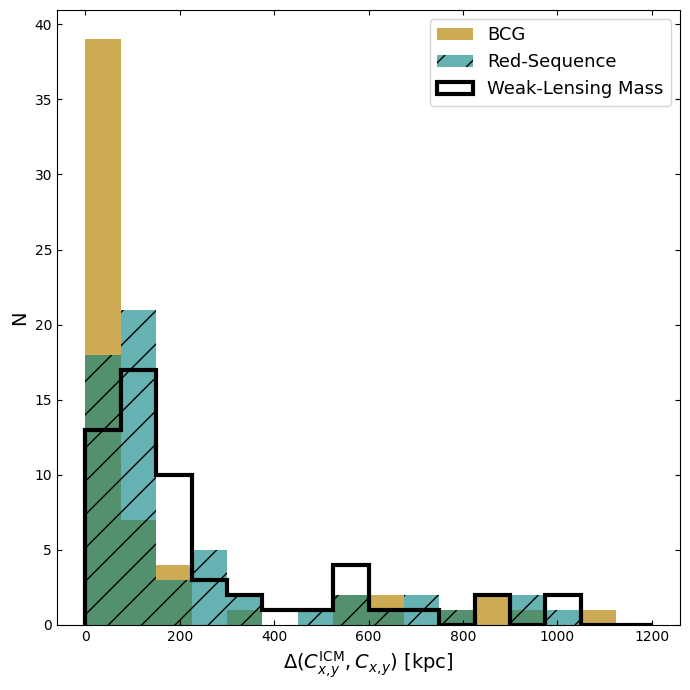

In [17]:
# Configures the histogram
step_size = 75
bins = np.arange(0, 1200+step_size, step_size)

# Makes the matplotlib figure
plt.figure(figsize=(7, 7))

plt.minorticks_off()
plt.tick_params(which='both', direction='in', top=True, right=True)

# BCG separation
plt.hist(prop_delta_icm_bcg.value, bins=bins, alpha=0.7, histtype='stepfilled', color="darkgoldenrod", 
         linewidth=3, label="BCG")
# RS separation
plt.hist(prop_delta_icm_red_seq.value, bins=bins, alpha=0.6, histtype='stepfilled', color="teal", 
         linewidth=3, label="Red-Sequence", hatch='/')
# Mass dist. separation
plt.hist(prop_delta_icm_wlm.value, bins=bins, alpha=1, histtype='step', color="black", 
         linewidth=3, label="Weak-Lensing Mass")

plt.ylabel('N', fontsize=14)
plt.xlabel(r'$\Delta(C^{\rm{ICM}}_{x,\!y}, C_{x,\!y})$ [kpc]', fontsize=14)

plt.legend(loc='best', fontsize=13)
plt.tight_layout()
plt.savefig(sep_fig_path + "delta_icm-bcg_rs_wlm_centroid_dist.pdf")
plt.show()

### Fraction of separations within different radii

#### ICM-BCG

In [18]:
nonan_prop_delta_icm_bcg = prop_delta_icm_bcg[~np.isnan(prop_delta_icm_bcg)]
icm_bcg_num_all = len(nonan_prop_delta_icm_bcg)

icm_bcg_num_10kpc = (nonan_prop_delta_icm_bcg < Quantity(10, 'kpc')).sum()
icm_bcg_num_20kpc = (nonan_prop_delta_icm_bcg < Quantity(20, 'kpc')).sum()
icm_bcg_num_50kpc = (nonan_prop_delta_icm_bcg < Quantity(50, 'kpc')).sum()
icm_bcg_num_100kpc = (nonan_prop_delta_icm_bcg < Quantity(100, 'kpc')).sum()
icm_bcg_num_200kpc = (nonan_prop_delta_icm_bcg < Quantity(200, 'kpc')).sum()

print(icm_bcg_num_10kpc, 'out of', icm_bcg_num_all, '({p}%) have ICM-BCG separations less than 10 ' \
      'kpc.'.format(p=round(100*(icm_bcg_num_10kpc/icm_bcg_num_all), 1)))
print(icm_bcg_num_20kpc, 'out of', icm_bcg_num_all, '({p}%) have ICM-BCG separations less than 20 ' \
      'kpc.'.format(p=round(100*(icm_bcg_num_20kpc/icm_bcg_num_all), 1)))
print(icm_bcg_num_50kpc, 'out of', icm_bcg_num_all, '({p}%) have ICM-BCG separations less than 50 ' \
      'kpc.'.format(p=round(100*(icm_bcg_num_50kpc/icm_bcg_num_all), 1)))
print(icm_bcg_num_100kpc, 'out of', icm_bcg_num_all, '({p}%) have ICM-BCG separations less than 100 ' \
      'kpc.'.format(p=round(100*(icm_bcg_num_100kpc/icm_bcg_num_all), 1)))
print(icm_bcg_num_200kpc, 'out of', icm_bcg_num_all, '({p}%) have ICM-BCG separations less than 200 ' \
      'kpc.'.format(p=round(100*(icm_bcg_num_200kpc/icm_bcg_num_all), 1)))

12 out of 60 (20.0%) have ICM-BCG separations less than 10 kpc.
22 out of 60 (36.7%) have ICM-BCG separations less than 20 kpc.
38 out of 60 (63.3%) have ICM-BCG separations less than 50 kpc.
41 out of 60 (68.3%) have ICM-BCG separations less than 100 kpc.
50 out of 60 (83.3%) have ICM-BCG separations less than 200 kpc.


#### ICM-Red Sequence

In [19]:
nonan_prop_delta_icm_red_seq = prop_delta_icm_red_seq[~np.isnan(prop_delta_icm_red_seq)]
icm_red_seq_num_all = len(nonan_prop_delta_icm_red_seq)

icm_red_seq_num_10kpc = (nonan_prop_delta_icm_red_seq < Quantity(10, 'kpc')).sum()
icm_red_seq_num_20kpc = (nonan_prop_delta_icm_red_seq < Quantity(20, 'kpc')).sum()
icm_red_seq_num_50kpc = (nonan_prop_delta_icm_red_seq < Quantity(50, 'kpc')).sum()
icm_red_seq_num_100kpc = (nonan_prop_delta_icm_red_seq < Quantity(100, 'kpc')).sum()
icm_red_seq_num_200kpc = (nonan_prop_delta_icm_red_seq < Quantity(200, 'kpc')).sum()

print(icm_red_seq_num_10kpc, 'out of', icm_red_seq_num_all, '({p}%) have ICM-RS separations less than 10 ' \
      'kpc.'.format(p=round(100*(icm_red_seq_num_10kpc/icm_red_seq_num_all), 1)))
print(icm_red_seq_num_20kpc, 'out of', icm_red_seq_num_all, '({p}%) have ICM-RS separations less than 20 ' \
      'kpc.'.format(p=round(100*(icm_red_seq_num_20kpc/icm_red_seq_num_all), 1)))
print(icm_red_seq_num_50kpc, 'out of', icm_red_seq_num_all, '({p}%) have ICM-RS separations less than 50 ' \
      'kpc.'.format(p=round(100*(icm_red_seq_num_50kpc/icm_red_seq_num_all), 1)))
print(icm_red_seq_num_100kpc, 'out of', icm_red_seq_num_all, '({p}%) have ICM-RS separations less than 100 ' \
      'kpc.'.format(p=round(100*(icm_red_seq_num_100kpc/icm_red_seq_num_all), 1)))
print(icm_red_seq_num_200kpc, 'out of', icm_red_seq_num_all, '({p}%) have ICM-RS separations less than 200 ' \
      'kpc.'.format(p=round(100*(icm_red_seq_num_200kpc/icm_red_seq_num_all), 1)))

0 out of 59 (0.0%) have ICM-RS separations less than 10 kpc.
1 out of 59 (1.7%) have ICM-RS separations less than 20 kpc.
7 out of 59 (11.9%) have ICM-RS separations less than 50 kpc.
27 out of 59 (45.8%) have ICM-RS separations less than 100 kpc.
42 out of 59 (71.2%) have ICM-RS separations less than 200 kpc.


#### ICM-WLM

In [20]:
nonan_prop_delta_icm_wlm = prop_delta_icm_wlm[~np.isnan(prop_delta_icm_wlm)]
icm_wlm_num_all = len(nonan_prop_delta_icm_wlm)

icm_wlm_num_10kpc = (nonan_prop_delta_icm_wlm < Quantity(10, 'kpc')).sum()
icm_wlm_num_20kpc = (nonan_prop_delta_icm_wlm < Quantity(20, 'kpc')).sum()
icm_wlm_num_50kpc = (nonan_prop_delta_icm_wlm < Quantity(50, 'kpc')).sum()
icm_wlm_num_100kpc = (nonan_prop_delta_icm_wlm < Quantity(100, 'kpc')).sum()
icm_wlm_num_200kpc = (nonan_prop_delta_icm_wlm < Quantity(200, 'kpc')).sum()

print(icm_wlm_num_10kpc, 'out of', icm_wlm_num_all, '({p}%) have ICM-WLM separations less than 10 ' \
      'kpc.'.format(p=round(100*(icm_wlm_num_10kpc/icm_wlm_num_all), 1)))
print(icm_wlm_num_20kpc, 'out of', icm_wlm_num_all, '({p}%) have ICM-WLM separations less than 20 ' \
      'kpc.'.format(p=round(100*(icm_wlm_num_20kpc/icm_wlm_num_all), 1)))
print(icm_wlm_num_50kpc, 'out of', icm_wlm_num_all, '({p}%) have ICM-WLM separations less than 50 ' \
      'kpc.'.format(p=round(100*(icm_wlm_num_50kpc/icm_wlm_num_all), 1)))
print(icm_wlm_num_100kpc, 'out of', icm_wlm_num_all, '({p}%) have ICM-WLM separations less than 100 ' \
      'kpc.'.format(p=round(100*(icm_wlm_num_100kpc/icm_wlm_num_all), 1)))
print(icm_wlm_num_200kpc, 'out of', icm_wlm_num_all, '({p}%) have ICM-WLM separations less than 200 ' \
      'kpc.'.format(p=round(100*(icm_wlm_num_200kpc/icm_wlm_num_all), 1)))

1 out of 57 (1.8%) have ICM-WLM separations less than 10 kpc.
3 out of 57 (5.3%) have ICM-WLM separations less than 20 kpc.
11 out of 57 (19.3%) have ICM-WLM separations less than 50 kpc.
22 out of 57 (38.6%) have ICM-WLM separations less than 100 kpc.
38 out of 57 (66.7%) have ICM-WLM separations less than 200 kpc.


#### Writing to results file

In [21]:
data = [['ICM-BCG', icm_bcg_num_all, icm_bcg_num_10kpc, icm_bcg_num_20kpc, icm_bcg_num_50kpc, icm_bcg_num_100kpc, icm_bcg_num_200kpc], 
        ['ICM-RS', icm_red_seq_num_all, icm_red_seq_num_10kpc, icm_red_seq_num_20kpc, icm_red_seq_num_50kpc, icm_red_seq_num_100kpc, 
         icm_red_seq_num_200kpc],
        ['ICM-WLM', icm_wlm_num_all, icm_wlm_num_10kpc, icm_wlm_num_20kpc, icm_wlm_num_50kpc, icm_wlm_num_100kpc, icm_wlm_num_200kpc]]

frac_sep_within_summ = pd.DataFrame(data, columns=['components', 'tot_num', 'sep<10kpc', 'sep<20kpc', 'sep<50kpc', 
                                                   'sep<100kpc', 'sep<200kpc'])
frac_sep_within_summ.to_csv(sep_res_path + "icm_component_separation_frac_within_apertures.csv", index=False)
frac_sep_within_summ

,components,tot_num,sep<10kpc,sep<20kpc,sep<50kpc,sep<100kpc,sep<200kpc
0,ICM-BCG,60,12,22,38,41,50
1,ICM-RS,59,0,1,7,27,42
2,ICM-WLM,57,1,3,11,22,38


### Median and confidence limits of galaxy cluster component separations from ICM

In [22]:
# Median, lower, and upper confidence limits (specified at the top of the notebook) for ICM-BCG separation
med_delta_icm_bcg = np.nanmedian(prop_delta_icm_bcg).round(3)
low_delta_icm_bcg = np.nanpercentile(prop_delta_icm_bcg, (50 - (SEP_CONF_LEVEL/2))).round(3)
upp_delta_icm_bcg = np.nanpercentile(prop_delta_icm_bcg, (50 + (SEP_CONF_LEVEL/2))).round(3)
# Will also measure a sigma, just to have a single number to complement the confidence interval
std_delta_icm_bcg = np.nanstd(prop_delta_icm_bcg).round(3)

# Median, lower, and upper confidence limits (specified at the top of the notebook) for ICM-RS separation
med_delta_icm_rs500kpc = np.nanmedian(prop_delta_icm_red_seq).round(3)
low_delta_icm_rs500kpc = np.nanpercentile(prop_delta_icm_red_seq, (50 - (SEP_CONF_LEVEL/2))).round(3)
upp_delta_icm_rs500kpc = np.nanpercentile(prop_delta_icm_red_seq, (50 + (SEP_CONF_LEVEL/2))).round(3)
std_delta_icm_rs500kpc = np.nanstd(prop_delta_icm_red_seq).round(3)

# Median, lower, and upper confidence limits (specified at the top of the notebook) for ICM-WLM separation
med_delta_icm_wlm500kpc = np.nanmedian(prop_delta_icm_wlm).round(3)
low_delta_icm_wlm500kpc = np.nanpercentile(prop_delta_icm_wlm, (50 - (SEP_CONF_LEVEL/2))).round(3)
upp_delta_icm_wlm500kpc = np.nanpercentile(prop_delta_icm_wlm, (50 + (SEP_CONF_LEVEL/2))).round(3)
std_delta_icm_wlm500kpc = np.nanstd(prop_delta_icm_wlm).round(3)

We'll store this in a results file as well:

In [23]:
data = [['ICM-BCG', med_delta_icm_bcg, low_delta_icm_bcg, upp_delta_icm_bcg, std_delta_icm_bcg], 
        ['ICM-RS', med_delta_icm_rs500kpc, low_delta_icm_rs500kpc, upp_delta_icm_rs500kpc, std_delta_icm_rs500kpc],
        ['ICM-WLM', med_delta_icm_wlm500kpc, low_delta_icm_wlm500kpc, upp_delta_icm_wlm500kpc, std_delta_icm_wlm500kpc]]

alignment_summ = pd.DataFrame(data, columns=['components', 'separation', 'separation_{}%conf_low'.format(SEP_CONF_LEVEL), 
                                             'separation_{}%conf_upp'.format(SEP_CONF_LEVEL), 'separation_stddev'])
alignment_summ.to_csv(sep_res_path + "icm_component_absolute_separation.csv", index=False)
alignment_summ

,components,separation,separation_95.4%conf_low,separation_95.4%conf_upp,separation_stddev
0,ICM-BCG,33.752 kpc,3.321 kpc,907.735 kpc,271.941 kpc
1,ICM-RS,113.219 kpc,23.885 kpc,949.519 kpc,253.897 kpc
2,ICM-WLM,136.43 kpc,11.913 kpc,962.631 kpc,257.703 kpc


## Rotating $\Delta$RA and $\Delta$Dec to the ICM PA

Having already measured as-the-crow-flies Haversine separations between the ICM centroid, and centroids of other cluster components, we will measure separate X and Y separations - to try to give the comparison of component X & Y separations between different clusters any hope of being physically valid, we will rotate the coordinate system to be aligned with the position angle of the hot ICM.

First we read out the ICM position angles from the dataframe, for convenience:

In [24]:
# Reading out the position angle of the ICM
icm_pa = xlovoccs_samp['position_angle'].values

### Calculating angular and proper distance $\Delta$RA and $\Delta$Dec 

This time, rather than calculating the Haversine distance between the centroid coordinates of different components, we measure the differences in RA and Dec separately, then convert those angular differences into 'proper' distances for each cluster - this essentially encodes the X and Y separations of different components - but as X and Y are aligned with the definitions of North-South and West-East in our RA-Dec coordinate system, they can't be directly compared for different clusters, as they will be rotated in a variety of different directions:

In [25]:
ra_dec_delta_icm_bcg = bcg_cent - icm_cent
ra_dec_delta_icm_red_seq = red_seq_cent - icm_cent
ra_dec_delta_icm_wlm = wlm_cent - icm_cent

prop_ra_dec_delta_icm_bcg = ang_to_rad(ra_dec_delta_icm_bcg, xlovoccs_samp['MCXC_Redshift'].values[..., None], lovoccs_cosmo)
prop_ra_dec_delta_icm_red_seq = ang_to_rad(ra_dec_delta_icm_red_seq, xlovoccs_samp['MCXC_Redshift'].values[..., None], lovoccs_cosmo)
prop_ra_dec_delta_icm_wlm = ang_to_rad(ra_dec_delta_icm_wlm, xlovoccs_samp['MCXC_Redshift'].values[..., None], lovoccs_cosmo)

### Rotating to ICM-component separation parallel and perpendicular to the hot ICM position angle

With what is effectively an RA-Dec vector between the hot ICM centroid, and the centroids of the other cluster components, we can now rotate into a new coordinate system - in this system, the X and Y directions will be parallel and perpendicular to the semi-major axis of the ellipse we are describing the ICM with.

In [26]:
rot_ra_dec_delta_icm_bcg = []
rot_ra_dec_delta_icm_red_seq = []
rot_ra_dec_delta_icm_wlm = []

for cur_ind in range(0, len(prop_ra_dec_delta_icm_bcg)):
    cur_pa = icm_pa[cur_ind]
    cur_rot = np.array([[np.cos((cur_pa) * (np.pi/180)), -1 * np.sin((cur_pa) * (np.pi/180))], 
                        [np.sin((cur_pa) * (np.pi/180)), np.cos((cur_pa) * (np.pi/180))]])
    
    cur_icm_bcg = prop_ra_dec_delta_icm_bcg[cur_ind]
    cur_icm_red_seq = prop_ra_dec_delta_icm_red_seq[cur_ind]
    cur_icm_wlm = prop_ra_dec_delta_icm_wlm[cur_ind]
    
    rot_ra_dec_delta_icm_bcg.append(cur_rot @ cur_icm_bcg)
    rot_ra_dec_delta_icm_red_seq.append(cur_rot @ cur_icm_red_seq)
    rot_ra_dec_delta_icm_wlm.append(cur_rot @ cur_icm_wlm)

rot_ra_dec_delta_icm_bcg = Quantity(rot_ra_dec_delta_icm_bcg)
rot_ra_dec_delta_icm_red_seq = Quantity(rot_ra_dec_delta_icm_red_seq)
rot_ra_dec_delta_icm_wlm = Quantity(rot_ra_dec_delta_icm_wlm)

### Saving parallel and perpendicular separations to a results file

In [27]:
bi_sep_data = np.hstack([rot_ra_dec_delta_icm_bcg.value, rot_ra_dec_delta_icm_red_seq.value, rot_ra_dec_delta_icm_wlm.value]).round(5)
bi_sep_data = np.append(xlovoccs_samp['name'].values[..., None], bi_sep_data, axis=1)
bi_sep_cols = ['name', 'para_icm_bcg_kpc_sep', 'perp_icm_bcg_kpc_sep', 
               'para_icm_red_seq_kpc_sep', 'perp_icm_red_seq_kpc_sep',
               'para_icm_wlm_kpc_sep', 'perp_icm_wlm_kpc_sep']
bi_sep_df = pd.DataFrame(bi_sep_data, columns=bi_sep_cols)
bi_sep_df.to_csv(sep_res_path + "icm_component_centroid_parallel-perpendicular_separations.csv", index=False)
bi_sep_df

,name,para_icm_bcg_kpc_sep,perp_icm_bcg_kpc_sep,para_icm_red_seq_kpc_sep,perp_icm_red_seq_kpc_sep,para_icm_wlm_kpc_sep,perp_icm_wlm_kpc_sep
0,LoVoCCS-1,7.90391,-0.45754,146.14163,-6.47207,157.00254,56.13731
1,LoVoCCS-2,8.33723,33.05429,24.31311,20.20944,11.93968,33.07193
2,LoVoCCS-4,NaN,NaN,NaN,NaN,NaN,NaN
3,LoVoCCS-5,-110.52595,-35.33815,21.15631,27.60117,0.62357,-36.35839
4,LoVoCCS-7,-1.82102,52.53148,70.43515,-8.35951,10.64052,127.17875
...,...,...,...,...,...,...,...
61,LoVoCCS-121,364.94125,-696.33997,452.86306,-387.12723,608.71878,-399.60782
62,LoVoCCS-122,NaN,NaN,NaN,NaN,NaN,NaN
63,LoVoCCS-123,-840.23097,226.53062,-873.89086,244.85642,-835.6687,296.31146
64,LoVoCCS-131,-10.81259,2.46576,184.83225,-62.22478,-36.75744,-23.10703


### Are components preferentially separated parallel or perpendicular to the ICM? 

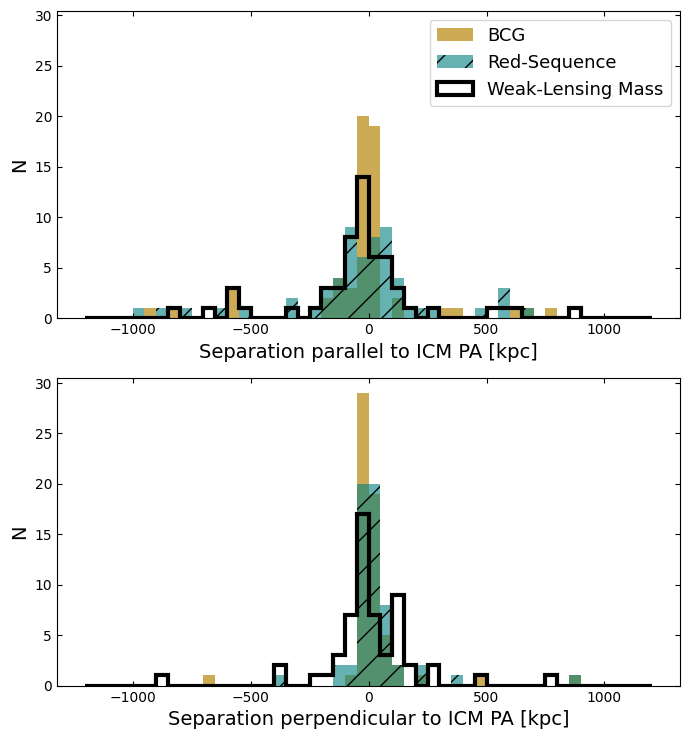

In [28]:
# Configures the histogram
step_size = 50
bins = np.arange(-1200, 1200+step_size, step_size)

# Makes the matplotlib figure
fig, ax_arr = plt.subplots(ncols=1, nrows=2, figsize=(7, 7.5), sharey=True)

ax_arr[0].minorticks_off()
ax_arr[0].tick_params(which='both', direction='in', top=True, right=True)
ax_arr[1].minorticks_off()
ax_arr[1].tick_params(which='both', direction='in', top=True, right=True)

plt.sca(ax_arr[0])

dens_hist = False

# BCG separation
plt.hist(rot_ra_dec_delta_icm_bcg[:, 0].value, bins=bins, alpha=0.7, histtype='stepfilled', color="darkgoldenrod", 
         linewidth=3, label="BCG", density=dens_hist)
# RS separation
plt.hist(rot_ra_dec_delta_icm_red_seq[:, 0].value, bins=bins, alpha=0.6, histtype='stepfilled', color="teal", 
         linewidth=3, label="Red-Sequence", hatch='/', density=dens_hist)
# Mass dist. separation
plt.hist(rot_ra_dec_delta_icm_wlm[:, 0].value, bins=bins, alpha=1, histtype='step', color="black", 
         linewidth=3, label="Weak-Lensing Mass", density=dens_hist)

plt.ylabel('N', fontsize=14)
plt.xlabel(r'Separation parallel to ICM PA [kpc]', fontsize=14)
plt.legend(loc='best', fontsize=13)

plt.sca(ax_arr[1])

# BCG separation
plt.hist(rot_ra_dec_delta_icm_bcg[:, 1].value, bins=bins, alpha=0.7, histtype='stepfilled', color="darkgoldenrod", 
         linewidth=3, label="BCG", density=dens_hist)
# RS separation
plt.hist(rot_ra_dec_delta_icm_red_seq[:, 1].value, bins=bins, alpha=0.6, histtype='stepfilled', color="teal", 
         linewidth=3, label="Red-Sequence", hatch='/', density=dens_hist)
# Mass dist. separation
plt.hist(rot_ra_dec_delta_icm_wlm[:, 1].value, bins=bins, alpha=1, histtype='step', color="black", 
         linewidth=3, label="Weak-Lensing Mass", density=dens_hist)

plt.ylabel('N', fontsize=14)
plt.xlabel(r'Separation perpendicular to ICM PA [kpc]', fontsize=14)

plt.tight_layout()
# plt.savefig(sep_fig_path + )
plt.show()

### Absolute separation parallel and perpendicular to the ICM

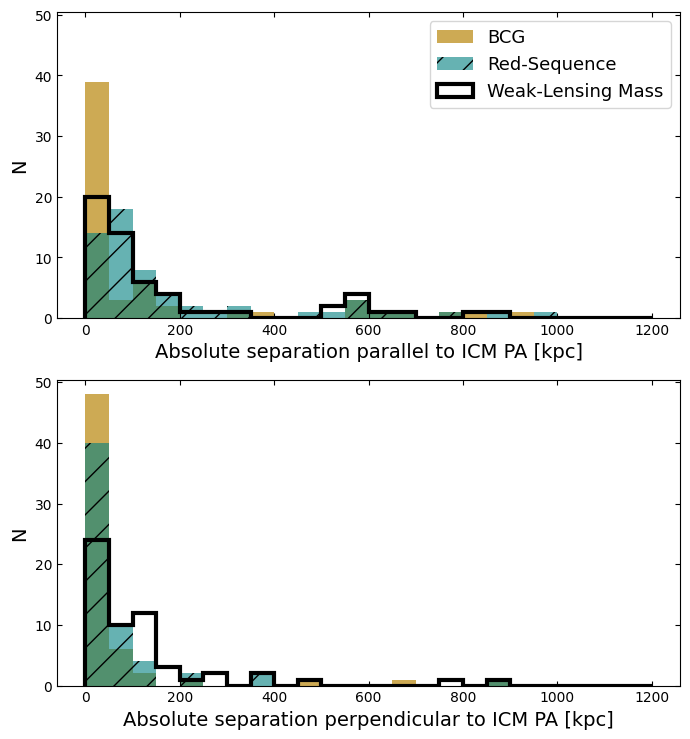

In [29]:
# Configures the histogram
step_size = 50
bins = np.arange(0, 1200+step_size, step_size)

# Makes the matplotlib figure
fig, ax_arr = plt.subplots(ncols=1, nrows=2, figsize=(7, 7.5), sharey=True)

ax_arr[0].minorticks_off()
ax_arr[0].tick_params(which='both', direction='in', top=True, right=True)
ax_arr[1].minorticks_off()
ax_arr[1].tick_params(which='both', direction='in', top=True, right=True)

plt.sca(ax_arr[0])

dens_hist = False

# BCG separation
plt.hist(np.abs(rot_ra_dec_delta_icm_bcg[:, 0].value), bins=bins, alpha=0.7, histtype='stepfilled', color="darkgoldenrod", 
         linewidth=3, label="BCG", density=dens_hist)
# RS separation
plt.hist(np.abs(rot_ra_dec_delta_icm_red_seq[:, 0].value), bins=bins, alpha=0.6, histtype='stepfilled', color="teal", 
         linewidth=3, label="Red-Sequence", hatch='/', density=dens_hist)
# Mass dist. separation
plt.hist(np.abs(rot_ra_dec_delta_icm_wlm[:, 0].value), bins=bins, alpha=1, histtype='step', color="black", 
         linewidth=3, label="Weak-Lensing Mass", density=dens_hist)

plt.ylabel('N', fontsize=14)
plt.xlabel(r'Absolute separation parallel to ICM PA [kpc]', fontsize=14)
plt.legend(loc='best', fontsize=13)

plt.sca(ax_arr[1])

# BCG separation
plt.hist(np.abs(rot_ra_dec_delta_icm_bcg[:, 1].value), bins=bins, alpha=0.7, histtype='stepfilled', color="darkgoldenrod", 
         linewidth=3, label="BCG", density=dens_hist)
# RS separation
plt.hist(np.abs(rot_ra_dec_delta_icm_red_seq[:, 1].value), bins=bins, alpha=0.6, histtype='stepfilled', color="teal", 
         linewidth=3, label="Red-Sequence", hatch='/', density=dens_hist)
# Mass dist. separation
plt.hist(np.abs(rot_ra_dec_delta_icm_wlm[:, 1].value), bins=bins, alpha=1, histtype='step', color="black", 
         linewidth=3, label="Weak-Lensing Mass", density=dens_hist)

plt.ylabel('N', fontsize=14)
plt.xlabel(r'Absolute separation perpendicular to ICM PA [kpc]', fontsize=14)

plt.tight_layout()
plt.savefig(sep_fig_path + 'icm_plane_abs_delta_icm-bcg_rs_wlm_centroid_dist.pdf')
plt.show()

### Fraction of parallel and perpendicular separations within different radii

In [30]:
ap_rads = Quantity([10, 20, 50, 100, 200], 'kpc')

#### ICM-BCG

In [31]:
abs_rot_icm_bcg_para = np.abs(rot_ra_dec_delta_icm_bcg[:, 0])[~np.isnan(rot_ra_dec_delta_icm_bcg[:, 0])]
abs_rot_icm_bcg_perp = np.abs(rot_ra_dec_delta_icm_bcg[:, 1])[~np.isnan(rot_ra_dec_delta_icm_bcg[:, 1])]

msg = "Of {t} total ICM-BCG separations, {pa} ({pap}%) parallel and {pe} ({pep}%) perpendicular separations are less than {r}."
for ap_rad in ap_rads:

    num_para_within = (abs_rot_icm_bcg_para < ap_rad).sum()
    num_perp_within = (abs_rot_icm_bcg_perp < ap_rad).sum()
    cur_tot = len(abs_rot_icm_bcg_para)

    print(msg.format(t=cur_tot, pa=num_para_within, pap=round(100*(num_para_within/cur_tot), 2), 
                     pe=num_perp_within, pep=round(100*(num_perp_within/cur_tot), 2), r=ap_rad))

Of 60 total ICM-BCG separations, 21 (35.0%) parallel and 24 (40.0%) perpendicular separations are less than 10.0 kpc.
Of 60 total ICM-BCG separations, 29 (48.33%) parallel and 35 (58.33%) perpendicular separations are less than 20.0 kpc.
Of 60 total ICM-BCG separations, 39 (65.0%) parallel and 48 (80.0%) perpendicular separations are less than 50.0 kpc.
Of 60 total ICM-BCG separations, 42 (70.0%) parallel and 54 (90.0%) perpendicular separations are less than 100.0 kpc.
Of 60 total ICM-BCG separations, 50 (83.33%) parallel and 56 (93.33%) perpendicular separations are less than 200.0 kpc.


#### ICM-Red Sequence

In [32]:
abs_rot_icm_red_seq_para = np.abs(rot_ra_dec_delta_icm_red_seq[:, 0])[~np.isnan(rot_ra_dec_delta_icm_red_seq[:, 0])]
abs_rot_icm_red_seq_perp = np.abs(rot_ra_dec_delta_icm_red_seq[:, 1])[~np.isnan(rot_ra_dec_delta_icm_red_seq[:, 1])]

msg = "Of {t} total ICM-RS separations, {pa} ({pap}%) parallel and {pe} ({pep}%) perpendicular separations are less than {r}."
for ap_rad in ap_rads:

    num_para_within = (abs_rot_icm_red_seq_para < ap_rad).sum()
    num_perp_within = (abs_rot_icm_red_seq_perp < ap_rad).sum()
    cur_tot = len(abs_rot_icm_red_seq_para)

    print(msg.format(t=cur_tot, pa=num_para_within, pap=round(100*(num_para_within/cur_tot), 2), 
                     pe=num_perp_within, pep=round(100*(num_perp_within/cur_tot), 2), r=ap_rad))

Of 59 total ICM-RS separations, 3 (5.08%) parallel and 9 (15.25%) perpendicular separations are less than 10.0 kpc.
Of 59 total ICM-RS separations, 4 (6.78%) parallel and 17 (28.81%) perpendicular separations are less than 20.0 kpc.
Of 59 total ICM-RS separations, 14 (23.73%) parallel and 40 (67.8%) perpendicular separations are less than 50.0 kpc.
Of 59 total ICM-RS separations, 32 (54.24%) parallel and 50 (84.75%) perpendicular separations are less than 100.0 kpc.
Of 59 total ICM-RS separations, 44 (74.58%) parallel and 54 (91.53%) perpendicular separations are less than 200.0 kpc.


#### ICM-WLM

In [33]:
abs_rot_icm_wlm_para = np.abs(rot_ra_dec_delta_icm_wlm[:, 0])[~np.isnan(rot_ra_dec_delta_icm_wlm[:, 0])]
abs_rot_icm_wlm_perp = np.abs(rot_ra_dec_delta_icm_wlm[:, 1])[~np.isnan(rot_ra_dec_delta_icm_wlm[:, 1])]

msg = "Of {t} total ICM-WLM separations, {pa} ({pap}%) parallel and {pe} ({pep}%) perpendicular separations are less than {r}."
for ap_rad in ap_rads:
    num_para_within = (abs_rot_icm_wlm_para < ap_rad).sum()
    num_perp_within = (abs_rot_icm_wlm_perp < ap_rad).sum()
    cur_tot = len(abs_rot_icm_wlm_para)

    print(msg.format(t=cur_tot, pa=num_para_within, pap=round(100*(num_para_within/cur_tot), 2), 
                     pe=num_perp_within, pep=round(100*(num_perp_within/cur_tot), 2), r=ap_rad))

Of 57 total ICM-WLM separations, 5 (8.77%) parallel and 6 (10.53%) perpendicular separations are less than 10.0 kpc.
Of 57 total ICM-WLM separations, 12 (21.05%) parallel and 9 (15.79%) perpendicular separations are less than 20.0 kpc.
Of 57 total ICM-WLM separations, 20 (35.09%) parallel and 24 (42.11%) perpendicular separations are less than 50.0 kpc.
Of 57 total ICM-WLM separations, 34 (59.65%) parallel and 34 (59.65%) perpendicular separations are less than 100.0 kpc.
Of 57 total ICM-WLM separations, 44 (77.19%) parallel and 49 (85.96%) perpendicular separations are less than 200.0 kpc.


### Median and confidence limits of galaxy cluster component separations from ICM

#### Parallel

In [34]:
# Median, lower, and upper confidence limits (specified at the top of the notebook) for ICM-BCG separation
med_delta_icm_bcg_para = np.nanmedian(abs_rot_icm_bcg_para).round(3)
low_delta_icm_bcg_para = np.nanpercentile(abs_rot_icm_bcg_para, (50 - (SEP_CONF_LEVEL/2))).round(3)
upp_delta_icm_bcg_para = np.nanpercentile(abs_rot_icm_bcg_para, (50 + (SEP_CONF_LEVEL/2))).round(3)
# Will also measure a sigma, just to have a single number to complement the confidence interval
std_delta_icm_bcg_para = np.nanstd(abs_rot_icm_bcg_para).round(3)

# Median, lower, and upper confidence limits (specified at the top of the notebook) for ICM-RS separation
med_delta_icm_rs500kpc_para = np.nanmedian(abs_rot_icm_red_seq_para).round(3)
low_delta_icm_rs500kpc_para = np.nanpercentile(abs_rot_icm_red_seq_para, (50 - (SEP_CONF_LEVEL/2))).round(3)
upp_delta_icm_rs500kpc_para = np.nanpercentile(abs_rot_icm_red_seq_para, (50 + (SEP_CONF_LEVEL/2))).round(3)
std_delta_icm_rs500kpc_para = np.nanstd(abs_rot_icm_red_seq_para).round(3)

# Median, lower, and upper confidence limits (specified at the top of the notebook) for ICM-WLM separation
med_delta_icm_wlm500kpc_para = np.nanmedian(abs_rot_icm_wlm_para).round(3)
low_delta_icm_wlm500kpc_para = np.nanpercentile(abs_rot_icm_wlm_para, (50 - (SEP_CONF_LEVEL/2))).round(3)
upp_delta_icm_wlm500kpc_para = np.nanpercentile(abs_rot_icm_wlm_para, (50 + (SEP_CONF_LEVEL/2))).round(3)
std_delta_icm_wlm500kpc_para = np.nanstd(abs_rot_icm_wlm_para).round(3)

We'll store this in a results file as well:

In [35]:
data = [['ICM-BCG', med_delta_icm_bcg_para, low_delta_icm_bcg_para, upp_delta_icm_bcg_para, std_delta_icm_bcg_para], 
        ['ICM-RS', med_delta_icm_rs500kpc_para, low_delta_icm_rs500kpc_para, upp_delta_icm_rs500kpc_para, std_delta_icm_rs500kpc_para],
        ['ICM-WLM', med_delta_icm_wlm500kpc_para, low_delta_icm_wlm500kpc_para, upp_delta_icm_wlm500kpc_para, std_delta_icm_wlm500kpc_para]]

para_alignment_summ = pd.DataFrame(data, columns=['components', 'separation', 'separation_{}%conf_low'.format(SEP_CONF_LEVEL), 
                                             'separation_{}%conf_upp'.format(SEP_CONF_LEVEL), 'separation_stddev'])
para_alignment_summ.to_csv(sep_res_path + "icm_component_absolute_parallel_separation.csv", index=False)
para_alignment_summ

,components,separation,separation_95.4%conf_low,separation_95.4%conf_upp,separation_stddev
0,ICM-BCG,20.782 kpc,1.091 kpc,809.698 kpc,233.892 kpc
1,ICM-RS,89.17 kpc,8.995 kpc,844.911 kpc,230.995 kpc
2,ICM-WLM,79.854 kpc,1.152 kpc,784.384 kpc,224.682 kpc


#### Perpendicular

In [36]:
# Median, lower, and upper confidence limits (specified at the top of the notebook) for ICM-BCG separation
med_delta_icm_bcg_perp = np.nanmedian(abs_rot_icm_bcg_perp).round(3)
low_delta_icm_bcg_perp = np.nanpercentile(abs_rot_icm_bcg_perp, (50 - (SEP_CONF_LEVEL/2))).round(3)
upp_delta_icm_bcg_perp = np.nanpercentile(abs_rot_icm_bcg_perp, (50 + (SEP_CONF_LEVEL/2))).round(3)
# Will also measure a sigma, just to have a single number to complement the confidence interval
std_delta_icm_bcg_perp = np.nanstd(abs_rot_icm_bcg_perp).round(3)

# Median, lower, and upper confidence limits (specified at the top of the notebook) for ICM-RS separation
med_delta_icm_rs500kpc_perp = np.nanmedian(abs_rot_icm_red_seq_perp).round(3)
low_delta_icm_rs500kpc_perp = np.nanpercentile(abs_rot_icm_red_seq_perp, (50 - (SEP_CONF_LEVEL/2))).round(3)
upp_delta_icm_rs500kpc_perp = np.nanpercentile(abs_rot_icm_red_seq_perp, (50 + (SEP_CONF_LEVEL/2))).round(3)
std_delta_icm_rs500kpc_perp = np.nanstd(abs_rot_icm_red_seq_perp).round(3)

# Median, lower, and upper confidence limits (specified at the top of the notebook) for ICM-WLM separation
med_delta_icm_wlm500kpc_perp = np.nanmedian(abs_rot_icm_wlm_perp).round(3)
low_delta_icm_wlm500kpc_perp = np.nanpercentile(abs_rot_icm_wlm_perp, (50 - (SEP_CONF_LEVEL/2))).round(3)
upp_delta_icm_wlm500kpc_perp = np.nanpercentile(abs_rot_icm_wlm_perp, (50 + (SEP_CONF_LEVEL/2))).round(3)
std_delta_icm_wlm500kpc_perp = np.nanstd(abs_rot_icm_wlm_perp).round(3)

We'll store this in a results file as well:

In [37]:
data = [['ICM-BCG', med_delta_icm_bcg_perp, low_delta_icm_bcg_perp, upp_delta_icm_bcg_perp, std_delta_icm_bcg_perp], 
        ['ICM-RS', med_delta_icm_rs500kpc_perp, low_delta_icm_rs500kpc_perp, upp_delta_icm_rs500kpc_perp, std_delta_icm_rs500kpc_perp],
        ['ICM-WLM', med_delta_icm_wlm500kpc_perp, low_delta_icm_wlm500kpc_perp, upp_delta_icm_wlm500kpc_perp, std_delta_icm_wlm500kpc_perp]]

perp_alignment_summ = pd.DataFrame(data, columns=['components', 'separation', 'separation_{}%conf_low'.format(SEP_CONF_LEVEL), 
                                             'separation_{}%conf_upp'.format(SEP_CONF_LEVEL), 'separation_stddev'])
perp_alignment_summ.to_csv(sep_res_path + "icm_component_absolute_perpendicular_separation.csv", index=False)
perp_alignment_summ

,components,separation,separation_95.4%conf_low,separation_95.4%conf_upp,separation_stddev
0,ICM-BCG,14.93 kpc,0.377 kpc,611.049 kpc,150.82 kpc
1,ICM-RS,34.667 kpc,1.061 kpc,394.885 kpc,129.383 kpc
2,ICM-WLM,56.463 kpc,2.311 kpc,705.094 kpc,167.727 kpc
